##     Case study iMM904 curation
 Using the iMM904 model as a case study, we have used Thermo-Flux and did the few manual curation steps to show how models can be converted into a combined thermodynamic-stoichiometric model.
Here, we present the steps that required manual attention when following the protocol described in the publication. "
    

In [2]:
import cobra
from cobra import Model, Reaction, Metabolite
import sys
import os 

sys.path.append(f'{os.getcwd()}/../../')
from thermo_flux.core.metabolite import ThermoMetabolite
import thermo_flux
from thermo_flux.io import load_excel as ex
from thermo_flux.core.model import ThermoModel, ThermoReaction
from equilibrator_api import  Q_
import pandas as pd
from thermo_flux.io import load_gams as gs
from thermo_flux.io import helper_load as hl
from thermo_flux.utils.vis import compare_met
import numpy as np
import gurobipy as  gp
from gurobipy import GRB


import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
PLOTTING_DATA_FOLDER='data_forplotting/'

### Analysis and plots for results figure  6d

In [4]:
#formating
sys.path.append('/home/nathan/PhD/04.Computational/202601_13C/3_src/')
import analysis.io_func as io_func
##specific paper
sns.set_palette('viridis')
OUTPUT_FOLDER='./Figures/'
def scale_rcparams(fig,scalingf=None):
    default_figsize = (5, 5)
    current_figsize = fig.get_size_inches()
    scale_x = current_figsize[0] / default_figsize[0]
    scale_y = current_figsize[1] / default_figsize[1]
    scale = min(scale_x, scale_y) if scalingf is None else scalingf
    
    # Update rcParams with scaled values
    plt.rcParams['axes.linewidth'] = 2.05 * scale
    plt.rcParams['lines.linewidth'] = 1.5 * scale
    plt.rcParams['font.size'] = 12.5# 25 * scale #fixed size of 12.5 for all
    plt.rcParams['xtick.major.size'] = 9.84 * scale
    plt.rcParams['ytick.major.size'] = 9.84 * scale
    plt.rcParams['xtick.minor.size'] = 6.56 * scale
    plt.rcParams['ytick.minor.size'] = 6.56 * scale
    #width
    # 'ytick.minor.width': 1.0
    plt.rcParams['xtick.major.width'] = 2.05 * scale
    plt.rcParams['ytick.major.width'] = 2.05 * scale
    plt.rcParams['xtick.minor.width'] = 1.64 * scale
    plt.rcParams['ytick.minor.width'] = 1.64 * scale
    # plt.rcParams['lines.linewidth'] = 1.5 * scale
    plt.rcParams['legend.fontsize'] = 12.5#5 * scale
    plt.rcParams['xtick.labelsize'] =12.5 #25 * scale
    plt.rcParams['ytick.labelsize'] = 12.5#25 * scale
    plt.rcParams['axes.labelsize'] =12.5# 25 * scale
    
    return plt.rcParams

def rescale_axlim(ax,how='both',nbins=4):
    def rescale_ylim(ax,nbins):
        yticks = ax.get_yticks()
        ax.set_yticks(np.linspace(yticks[0], yticks[-1], nbins))
        return ax
    def rescale_xlim(ax,nbins):
        xticks = ax.get_xticks()
        ax.set_xticks(np.linspace(xticks[0], xticks[-1], nbins))
        return ax
    if how=='both':
        ax=rescale_ylim(rescale_xlim(ax,nbins),nbins)
    elif how=='x':
        ax=rescale_xlim(ax,nbins)
    elif how=='y':
        ax=rescale_ylim(ax,nbins)
    return ax

### d) compare TFBA gur-scan predictions with experimental data

In [5]:
#plot biomass yield for stoichiometric model with balanced reactions and pH specified
df_data2 = pd.read_csv('plotting_Yeast_ALL_experimental_data.csv',index_col=0)
df_data2['regression'].fillna('Not fitted',inplace=True)
df_data2['regression'].replace('yes', 'Fitted', inplace=True)
df_data2.rename(columns={'regression':'Exp. data'}, inplace=True)
#rename index in Condition
df_data2.index.rename('Condition', inplace=True)




A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.




### load from here the saved df

In [6]:
ex_flux_df=pd.read_csv(f'{PLOTTING_DATA_FOLDER}/scatter_validation_exp_TFBAfluxes.csv',index_col=0)

#exp df (also above)
df_data2 = pd.read_csv('plotting_Yeast_ALL_experimental_data.csv',index_col=0)
df_data2['regression'].fillna('Not fitted',inplace=True)
df_data2['regression'].replace('yes', 'Fitted', inplace=True)
df_data2.rename(columns={'regression':'Exp. data'}, inplace=True)
#rename index in Condition
df_data2.index.rename('Condition', inplace=True)

ex_data=['biomass_EX', 'EX_ac_e', 'EX_glyc_e', 'co2_EX', 'etoh_EX', 'o2_EX']




A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.




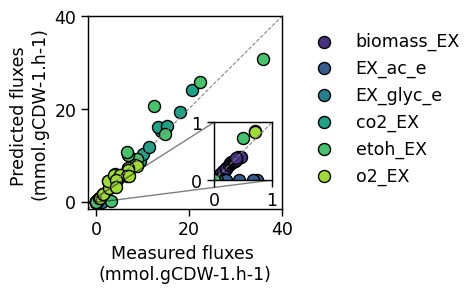

In [11]:
## scatter plot conditions vs fluxes

fig, ax = plt.subplots(figsize=(2.5,2.5))
axin=ax.inset_axes([0.65,0.15,0.3,0.3])

scale_rcparams(fig)
mapping_rxnnames={'biomass_EX':'biomass_EX','EX_ac_e':'ac_EX','EX_glyc_e':'glyc_EX','co2_EX':'co2tot_EX','etoh_EX':'etoh_EX','o2_EX':'o2_EX'}
vircols=sns.color_palette('viridis',n_colors=len(ex_data))
for rxn,color in zip(ex_data,vircols):
    x=df_data2[mapping_rxnnames[rxn]]
    y=ex_flux_df.loc[rxn] #if rxn not in ['o2_EX'] else -ex_flux_df.loc[rxn]
    ax.scatter(x,y,s=75,edgecolor='black',color=color,label=rxn)

    ## add an inset ax with zoom bottom right
    axin.scatter(x,y,s=75,edgecolor='black',color=color)

#fformating
ax.set_xlabel('Measured fluxes \n(mmol.gCDW-1.h-1)')
ax.set_ylabel('Predicted fluxes \n(mmol.gCDW-1.h-1)')
#diag
ax.plot([0,1],[0,1],transform=ax.transAxes,color='grey',linestyle='--')
ax.legend(frameon=False,bbox_to_anchor=(1.05, 1))
ax.set_xticks([0,20,40])
ax.set_yticks([0,20,40])


axin.plot([0,1],[0,1],transform=axin.transAxes,color='grey',linestyle='--')
axin.set_xlim(0,1)
axin.set_ylim(0,1)
axin.set_xticks([0,1])
axin.set_yticks([0,1])
axin.set_xlabel('')
axin.set_ylabel('')
ax.indicate_inset_zoom(axin,edgecolor='black')

#save 
# plt.savefig(f'{OUTPUT_FOLDER}/scatter_predictions_allglucoseconds.png',dpi=300)
# plt.savefig(f'{OUTPUT_FOLDER}/scatter_predictions_allglucoseconds.svg',dpi=300)

### compare with loopless fba 

In [ ]:
looplessfba_exflux=pd.read_csv(f'{PLOTTING_DATA_FOLDER}/scatter_validation_exp_loopless.csv',index_col=0)
looplessfba_exflux

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
biomass_EX,2.534511,3.250443,0.040794,0.093011,0.097906,0.179495,0.272505,0.349199,0.362253,0.461791,0.528693,0.603755,0.762036,0.887682,1.243408,1.320101,1.359264,1.669300,2.150672
EX_ac_e,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
EX_glyc_e,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
co2_EX,3.104520,17.692468,0.019323,0.077002,0.081055,0.148600,0.225602,0.289095,0.299902,0.382307,0.437694,0.499836,0.630874,0.734894,1.029393,1.092885,1.125307,1.381980,1.780498
etoh_EX,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
o2_EX,-1.287681,-15.362420,-0.004530,-0.010328,-0.010871,-0.019931,-0.030259,-0.038775,-0.040225,-0.051277,-0.058706,-0.067041,-0.084616,-0.098568,-0.138068,-0.146584,-0.150933,-0.185359,-0.238811


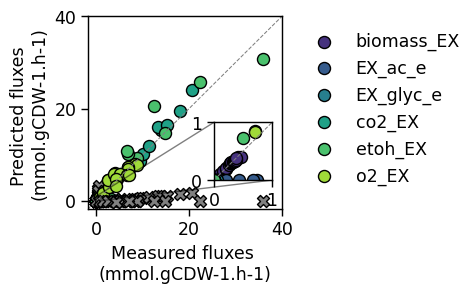

In [ ]:
## scatter plot conditions vs fluxes

fig, ax = plt.subplots(figsize=(2.5,2.5))
axin=ax.inset_axes([0.65,0.15,0.3,0.3])

scale_rcparams(fig)
mapping_rxnnames={'biomass_EX':'biomass_EX','EX_ac_e':'ac_EX','EX_glyc_e':'glyc_EX','co2_EX':'co2tot_EX','etoh_EX':'etoh_EX','o2_EX':'o2_EX'}
vircols=sns.color_palette('viridis',n_colors=len(ex_data))
for rxn,color in zip(ex_data,vircols):
    x=df_data2[mapping_rxnnames[rxn]]
    y=ex_flux_df.loc[rxn] #if rxn not in ['o2_EX'] else -ex_flux_df.loc[rxn]
    ax.scatter(x,y,s=75,edgecolor='black',color=color,label=rxn)
    ##add scatter for loopless
    y_loopless=looplessfba_exflux.loc[rxn]
    ax.scatter(x,y_loopless,s=75,edgecolor='black',color='.5', marker='X')
    ## add an inset ax with zoom bottom right
    axin.scatter(x,y,s=75,edgecolor='black',color=color)


#fformating
ax.set_xlabel('Measured fluxes \n(mmol.gCDW-1.h-1)')
ax.set_ylabel('Predicted fluxes \n(mmol.gCDW-1.h-1)')
#diag
ax.plot([0,1],[0,1],transform=ax.transAxes,color='grey',linestyle='--')
ax.legend(frameon=False,bbox_to_anchor=(1.05, 1))
ax.set_xticks([0,20,40])
ax.set_yticks([0,20,40])


axin.plot([0,1],[0,1],transform=axin.transAxes,color='grey',linestyle='--')
axin.set_xlim(0,1)
axin.set_ylim(0,1)
axin.set_xticks([0,1])
axin.set_yticks([0,1])
axin.set_xlabel('')
axin.set_ylabel('')
ax.indicate_inset_zoom(axin,edgecolor='black')

#save 
# plt.savefig(f'{OUTPUT_FOLDER}/scatter_predictions_allglucoseconds_addloopless.png',dpi=300)
# plt.savefig(f'{OUTPUT_FOLDER}/scatter_predictions_allglucoseconds_addloopless.svg',dpi=300)

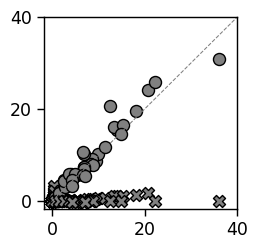

In [ ]:
fig, ax = plt.subplots(figsize=(2.5,2.5))

scale_rcparams(fig)
mapping_rxnnames={'biomass_EX':'biomass_EX','EX_ac_e':'ac_EX','EX_glyc_e':'glyc_EX','co2_EX':'co2tot_EX','etoh_EX':'etoh_EX','o2_EX':'o2_EX'}
vircols=sns.color_palette('viridis',n_colors=len(ex_data))
for rxn,color in zip(ex_data,vircols):
    x=df_data2[mapping_rxnnames[rxn]]
    y=ex_flux_df.loc[rxn]# if rxn not in ['o2_EX'] else -ex_flux_df.loc[rxn]
    ax.scatter(x,y,s=75,edgecolor='black',color='.5',label=rxn)
    ##now loopless, with a x
    y_loopless=looplessfba_exflux.loc[rxn]
    ax.scatter(x,y_loopless,s=75,edgecolor='black',color='.5',label=rxn, marker='X')
    # ## now parsimonious , with a ^ ## dont show parsimonious bc it is very similar
    # y_parsimonious=pfba_exflux.loc[rxn]
    # ax.scatter(x,y_parsimonious,s=75,color='.5',label=rxn, marker='^')
    # add an inset ax with zoom bottom right
    # axin.scatter(x,y,s=75,edgecolor='black',color=color)
ax.plot([0,1],[0,1],transform=ax.transAxes,color='grey',linestyle='--')
# ax.legend(frameon=False,bbox_to_anchor=(1.05, 1))
ax.set_xticks([0,20,40])
ax.set_yticks([0,20,40])
